In [ ]:
!git clone https://github.com/Jun1801/CoDraft-Bench.git

fatal: not a git repository (or any parent up to mount point /home/dell/Desktop)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


In [ ]:
%cd "YOUR_WORKING_DIR"

/home/dell/Desktop/data/duy_dev/legalAI/CoDraft-Bench


In [30]:
!pip install -r requirements.txt

In [ ]:
CD_PATH = "YOUR WORKING DIR"

In [32]:
import os
import sys
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

if CD_PATH not in sys.path:
    sys.path.append(CD_PATH)

In [ ]:
from copy import deepcopy
import numpy as np
import pandas as pd

from config import *
from preprocess import *
from model import *
from model.models import *
from utils import *


In [34]:
RANDOM_SEED = 42
set_seed(RANDOM_SEED)

data_generator = torch.Generator()
data_generator.manual_seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Random seed set to 42
Device: cuda


In [35]:
import torch

torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [36]:
%cd ..

/home/dell/Desktop/data/duy_dev/legalAI


In [37]:
INPUT_ROOT = "dataset"
WORK_DIR = "working"
MODEL_NAME = "BAAI/bge-reranker-v2-m3"
MODEL_TYPE = "multi_task"
CHECKPOINT_FILE = f"{WORK_DIR}/{MODEL_NAME}_best_model.pth"
PRETRAIN_FILE = None

In [38]:
tokenizer = get_tokenizer(MODEL_NAME)

In [39]:
data_manager = DataManager(
    input_root = INPUT_ROOT, 
    work_dir = WORK_DIR, 
    config_data = CONFIG_DATA,
    tokenizer=tokenizer,
    seed_worker = seed_worker,
    data_generator = data_generator,
    random_seed = RANDOM_SEED
)

Map: 100%|██████████| 8534/8534 [00:00<00:00, 9352.93 examples/s] 


In [40]:
train_ds, val_ds, test_ds = data_manager.get_dataset()
df_train, df_val, df_test = data_manager.get_data()

In [41]:
model, _ = get_model(model_type="multi_task", model_name=MODEL_NAME, 
                  num_classes=5, num_product_classes=45,
                 device=DEVICE, **CONFIG_MODEL.MODEL_CONFIG['multi_task']['loss_args'])

Some weights of JointClassSimBGE were not initialized from the model checkpoint at BAAI/bge-reranker-v2-m3 and are newly initialized: ['aux_classifier.bias', 'aux_classifier.weight', 'classifier.bias', 'classifier.weight', 'roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [42]:
training_args = get_training_args(**CONFIG_MODEL.MODEL_CONFIG['multi_task']['training_args'])

In [43]:
from transformers import Trainer, DataCollatorWithPadding
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)

print("Training...")
trainer.train()

Training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Qwk,Mae
1,2.111400,0.405074,0.868975,0.568688,0.915600,0.235611
2,0.597900,0.361197,0.894244,0.720557,0.934768,0.185774
3,0.332200,0.425735,0.904071,0.739569,0.942014,0.165653
4,0.354200,0.435181,0.910622,0.774265,0.946853,0.151614
5,0.178500,0.491965,0.916004,0.799714,0.944067,0.152550
6,0.003600,0.531490,0.920917,0.824745,0.946814,0.142489
7,0.000700,0.583722,0.921385,0.809401,0.946616,0.142255
8,0.004600,0.628352,0.921619,0.821646,0.945714,0.143425
9,0.000100,0.623636,0.924895,0.828523,0.946680,0.139448
10,0.000000,0.624650,0.923959,0.826505,0.946543,0.140384


TrainOutput(global_step=9350, training_loss=0.7185794351598557, metrics={'train_runtime': 3176.4536, 'train_samples_per_second': 94.099, 'train_steps_per_second': 2.944, 'total_flos': 7.051185222906422e+16, 'train_loss': 0.7185794351598557, 'epoch': 10.0})

In [44]:
test_preds, test_true = get_preds_multi(trainer, test_ds, df_test)

In [45]:
result_df = pd.DataFrame({
    "label": test_true,
    "pred": test_preds,
})

Per-class metrics (class | support | accuracy | precision | recall | f1):
 0 |   2360 | 0.9623 | 0.9633 | 0.9686 | 0.9660
 1 |    161 | 0.9789 | 0.7152 | 0.7329 | 0.7239
 2 |    544 | 0.9498 | 0.8011 | 0.8070 | 0.8040
 3 |     77 | 0.9873 | 0.6420 | 0.6753 | 0.6582
 4 |   1125 | 0.9688 | 0.9509 | 0.9298 | 0.9402

Overall accuracy: 0.9236
Micro Precision | Recall | F1: 0.9236 0.9236 0.9236
Macro Precision | Recall | F1: 0.8145 0.8227 0.8185
Mean Absolute Error (MAE): 0.1364
Quadratic Weighted Kappa (QWK): 0.9503

Confusion Matrix (Hàng = Thực tế, Cột = Dự đoán):
     P  0 P  1 P  2 P  3 P  4
   -----------------------------
T0 |2286  22  39   4   9
T1 |  24 118  15   0   4
T2 |  46  22 439   7  30
T3 |   5   1   8  52  11
T4 |  12   2  47  181046


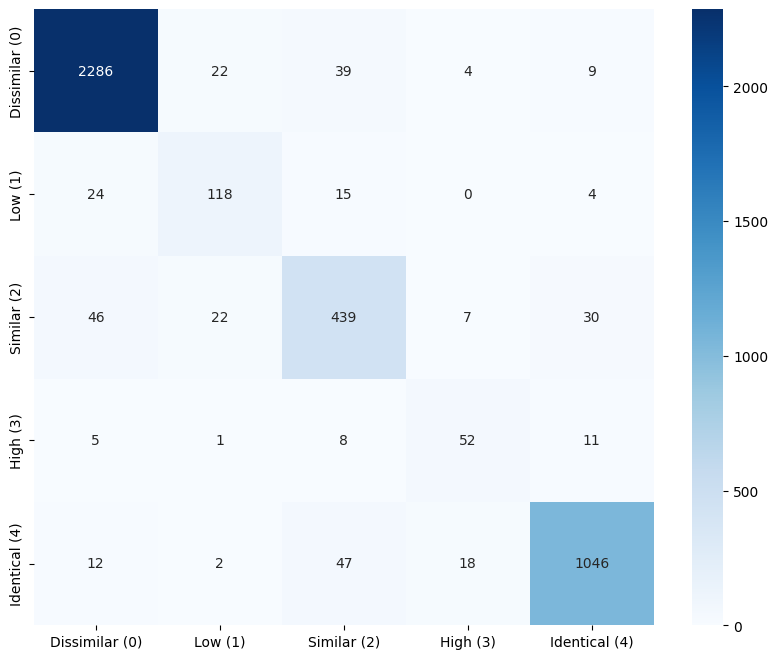

(0.9235997187719709, np.float64(0.1363955940942114), 0.9503330523272803)

In [ ]:
get_stats(result_df)

In [47]:
result_df.to_csv("result_df.csv", index=False)

In [48]:
save_model(trainer, tokenizer, MODEL_NAME, './model/checkpoint')

Saving: ./model/checkpoint ...
Success!


In [50]:
zip_model_folder("./model")

Đang nén folder: ./model ...
Đã nén thành công: ./model.zip
